### Binary and Ternary Classes in This Study Based on Mohs Hardness Values
Binary
0: (0.991, 5.5]
1: (5.5, 10.0]

Ternary
0: (0.991, 4.0]
1: (4.0, 7.0]
2: (7.0, 10.0]

### List of all Primary Features
- `allelectrons_Total`
- `density_Total`
- `allelectrons_Average`
- `val_e_Average`
- `atomicweight_Average`
- `ionenergy_Average`
- `el_neg_chi_Average`
- `R_vdw_element_Average`
- `R_cov_element_Average`
- `zaratio_Average`
- `density_Average`

### Train and Test Datasets
Train: Artificial_Crystals_Dataset.csv
Test: Mineral_Dataset_Supplementary_Info.csv

### ML Models Used
1. Binary RBF SVC
2. Ternary RBF SVC - OVO
3. Binary RF
4. Ternary RF - multiclass
5. Ternary RF - OVR: 0 versus 1, 2
6. Ternary RF - OVR: 1 versus 0, 2
7. Ternary RF - OVR: 2 versus 0, 1
8. Binary Matern SVC
9. Ternary Matern SVC - OVO

In [1]:
from pathlib import Path
import csv
from typing import Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [2]:
FEATURES = [
    "allelectrons_Total",
    "density_Total",
    "allelectrons_Average",
    "val_e_Average",
    "atomicweight_Average",
    "ionenergy_Average",
    "el_neg_chi_Average",
    "R_vdw_element_Average",
    "R_cov_element_Average",
    "zaratio_Average",
    "density_Average",
]

In [3]:
def binary_label_from_value(hardness: float) -> Optional[int]:
    if 0.991 < hardness <= 5.5:
        return 0
    if 5.5 < hardness <= 10.0:
        return 1
    return None


def ternary_label_from_value(hardness: float) -> Optional[int]:
    if 0.991 < hardness <= 4.0:
        return 0
    if 4.0 < hardness <= 7.0:
        return 1
    if 7.0 < hardness <= 10.0:
        return 2
    return None


def load_xy(csv_path: Path, hardness_column: str, label_fn=binary_label_from_value) -> Tuple[np.ndarray, np.ndarray]:
    x_rows = []
    y_rows = []
    with csv_path.open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                hardness = float(row[hardness_column])
                label_value = label_fn(hardness)
                if label_value is None:
                    continue
                feature_vector = [float(row[feature]) for feature in FEATURES]
            except (TypeError, ValueError, KeyError):
                continue
            x_rows.append(feature_vector)
            y_rows.append(label_value)
    return np.array(x_rows, dtype=float), np.array(y_rows, dtype=int)

In [4]:
# Get path and load data
base_dir = Path.cwd()
if not (base_dir / "data").exists() and (base_dir.parent / "data").exists():
    base_dir = base_dir.parent

# Prefer the local data folder in this project
data_dir = base_dir / "data"
X, y = load_xy(data_dir / "Mineral_Dataset_Supplementary_Info.csv", "Hardness")

### 1: Binary RBF SVC

In [5]:
splitter = StratifiedShuffleSplit(n_splits=500, train_size=2 / 3, test_size=1 / 3, random_state=42)
rbf_svc_binary = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", random_state=42)),
    ]
)

precision_scores = []
recall_scores = []
accuracy_scores = []
f1_scores = []
specificity_scores = []

for train_index, test_index in splitter.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    rbf_svc_binary.fit(X_train, y_train)
    y_test_pred = rbf_svc_binary.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_test, y_test_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    precision_scores.append(precision)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    specificity_scores.append(specificity)

metric_series = {
    "precision": np.array(precision_scores),
    "recall": np.array(recall_scores),
    "accuracy": np.array(accuracy_scores),
    "f1": np.array(f1_scores),
    "specificity": np.array(specificity_scores),
}

metric_stats = {
    metric_name: {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
    }
    for metric_name, values in metric_series.items()
}

model_performance = {
    "rbf_svc_binary": metric_stats,
}

for metric_name in ["precision", "recall", "accuracy", "f1", "specificity"]:
    stats = metric_stats[metric_name]
    print(f"{metric_name.capitalize()}: {stats['mean']:.4f} ± {stats['std']:.4f}")


Precision: 0.8369 ± 0.0236
Recall: 0.8360 ± 0.0239
Accuracy: 0.8360 ± 0.0239
F1: 0.8357 ± 0.0238
Specificity: 0.8798 ± 0.0298


### 2. Ternary RBF SVC - OVO

In [6]:
X_ternary, y_ternary = load_xy(
    data_dir / "Mineral_Dataset_Supplementary_Info.csv",
    "Hardness",
    label_fn=ternary_label_from_value,
)

splitter = StratifiedShuffleSplit(n_splits=500, train_size=2 / 3, test_size=1 / 3, random_state=42)
rbf_svc_ternary = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", decision_function_shape="ovo", random_state=42)),
    ]
)

precision_scores = []
recall_scores = []
accuracy_scores = []
f1_scores = []
specificity_scores = []

for train_index, test_index in splitter.split(X_ternary, y_ternary):
    X_train, X_test = X_ternary[train_index], X_ternary[test_index]
    y_train, y_test = y_ternary[train_index], y_ternary[test_index]

    rbf_svc_ternary.fit(X_train, y_train)
    y_test_pred = rbf_svc_ternary.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_test, y_test_pred)

    cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1, 2])
    per_class_specificity = []
    for class_idx in range(cm.shape[0]):
        tp = cm[class_idx, class_idx]
        fp = cm[:, class_idx].sum() - tp
        fn = cm[class_idx, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        class_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        per_class_specificity.append(class_specificity)
    specificity = float(np.mean(per_class_specificity))

    precision_scores.append(precision)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    specificity_scores.append(specificity)

metric_series_ternary = {
    "precision": np.array(precision_scores),
    "recall": np.array(recall_scores),
    "accuracy": np.array(accuracy_scores),
    "f1": np.array(f1_scores),
    "specificity": np.array(specificity_scores),
}

metric_stats_ternary = {
    metric_name: {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
    }
    for metric_name, values in metric_series_ternary.items()
}

model_performance["rbf_svc_ternary_ovo"] = metric_stats_ternary

for metric_name in ["precision", "recall", "accuracy", "f1", "specificity"]:
    stats = metric_stats_ternary[metric_name]
    print(f"{metric_name.capitalize()}: {stats['mean']:.4f} ± {stats['std']:.4f}")

Precision: 0.7942 ± 0.0304
Recall: 0.8053 ± 0.0228
Accuracy: 0.8053 ± 0.0228
F1: 0.7908 ± 0.0236
Specificity: 0.8638 ± 0.0156


### 3. Binary RF

In [7]:
splitter = StratifiedShuffleSplit(n_splits=500, train_size=2 / 3, test_size=1 / 3, random_state=42)
rf_binary = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)

precision_scores = []
recall_scores = []
accuracy_scores = []
f1_scores = []
specificity_scores = []

for train_index, test_index in splitter.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    rf_binary.fit(X_train, y_train)
    y_test_pred = rf_binary.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_test, y_test_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    precision_scores.append(precision)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    specificity_scores.append(specificity)

metric_series_binary_rf = {
    "precision": np.array(precision_scores),
    "recall": np.array(recall_scores),
    "accuracy": np.array(accuracy_scores),
    "f1": np.array(f1_scores),
    "specificity": np.array(specificity_scores),
}

metric_stats_binary_rf = {
    metric_name: {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
    }
    for metric_name, values in metric_series_binary_rf.items()
}

model_performance["rf_binary"] = metric_stats_binary_rf

for metric_name in ["precision", "recall", "accuracy", "f1", "specificity"]:
    stats = metric_stats_binary_rf[metric_name]
    print(f"{metric_name.capitalize()}: {stats['mean']:.4f} ± {stats['std']:.4f}")

Precision: 0.8624 ± 0.0212
Recall: 0.8631 ± 0.0205
Accuracy: 0.8631 ± 0.0205
F1: 0.8607 ± 0.0210
Specificity: 0.9250 ± 0.0248


### 4. Ternary RF - multiclass

In [8]:
splitter = StratifiedShuffleSplit(n_splits=500, train_size=2 / 3, test_size=1 / 3, random_state=42)
rf_ternary_multiclass = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)

precision_scores = []
recall_scores = []
accuracy_scores = []
f1_scores = []
specificity_scores = []

for train_index, test_index in splitter.split(X_ternary, y_ternary):
    X_train, X_test = X_ternary[train_index], X_ternary[test_index]
    y_train, y_test = y_ternary[train_index], y_ternary[test_index]

    rf_ternary_multiclass.fit(X_train, y_train)
    y_test_pred = rf_ternary_multiclass.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_test, y_test_pred)

    cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1, 2])
    per_class_specificity = []
    for class_idx in range(cm.shape[0]):
        tp = cm[class_idx, class_idx]
        fp = cm[:, class_idx].sum() - tp
        fn = cm[class_idx, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        class_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        per_class_specificity.append(class_specificity)
    specificity = float(np.mean(per_class_specificity))

    precision_scores.append(precision)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    specificity_scores.append(specificity)

metric_series_ternary_rf = {
    "precision": np.array(precision_scores),
    "recall": np.array(recall_scores),
    "accuracy": np.array(accuracy_scores),
    "f1": np.array(f1_scores),
    "specificity": np.array(specificity_scores),
}

metric_stats_ternary_rf = {
    metric_name: {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
    }
    for metric_name, values in metric_series_ternary_rf.items()
}

model_performance["rf_ternary_multiclass"] = metric_stats_ternary_rf

for metric_name in ["precision", "recall", "accuracy", "f1", "specificity"]:
    stats = metric_stats_ternary_rf[metric_name]
    print(f"{metric_name.capitalize()}: {stats['mean']:.4f} ± {stats['std']:.4f}")

Precision: 0.8430 ± 0.0251
Recall: 0.8487 ± 0.0209
Accuracy: 0.8487 ± 0.0209
F1: 0.8399 ± 0.0214
Specificity: 0.8994 ± 0.0139


### 5. Ternary RF - OVR: 0 versus 1, 2

In [9]:
y_ternary_ovr_0 = np.where(y_ternary == 0, 0, 1)

splitter = StratifiedShuffleSplit(n_splits=500, train_size=2 / 3, test_size=1 / 3, random_state=42)
rf_ternary_ovr_0 = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)

precision_scores = []
recall_scores = []
accuracy_scores = []
f1_scores = []
specificity_scores = []

for train_index, test_index in splitter.split(X_ternary, y_ternary_ovr_0):
    X_train, X_test = X_ternary[train_index], X_ternary[test_index]
    y_train, y_test = y_ternary_ovr_0[train_index], y_ternary_ovr_0[test_index]

    rf_ternary_ovr_0.fit(X_train, y_train)
    y_test_pred = rf_ternary_ovr_0.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_test, y_test_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    precision_scores.append(precision)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    specificity_scores.append(specificity)

metric_series_ternary_rf_ovr_0 = {
    "precision": np.array(precision_scores),
    "recall": np.array(recall_scores),
    "accuracy": np.array(accuracy_scores),
    "f1": np.array(f1_scores),
    "specificity": np.array(specificity_scores),
}

metric_stats_ternary_rf_ovr_0 = {
    metric_name: {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
    }
    for metric_name, values in metric_series_ternary_rf_ovr_0.items()
}

model_performance["rf_ternary_ovr_0_vs_12"] = metric_stats_ternary_rf_ovr_0

for metric_name in ["precision", "recall", "accuracy", "f1", "specificity"]:
    stats = metric_stats_ternary_rf_ovr_0[metric_name]
    print(f"{metric_name.capitalize()}: {stats['mean']:.4f} ± {stats['std']:.4f}")

Precision: 0.8864 ± 0.0207
Recall: 0.8855 ± 0.0208
Accuracy: 0.8855 ± 0.0208
F1: 0.8854 ± 0.0208
Specificity: 0.8530 ± 0.0408


### 6. Ternary RF - OVR: 1 versus 0, 2

In [10]:
y_ternary_ovr_1 = np.where(y_ternary == 1, 0, 1)

splitter = StratifiedShuffleSplit(n_splits=500, train_size=2 / 3, test_size=1 / 3, random_state=42)
rf_ternary_ovr_1 = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)

precision_scores = []
recall_scores = []
accuracy_scores = []
f1_scores = []
specificity_scores = []

for train_index, test_index in splitter.split(X_ternary, y_ternary_ovr_1):
    X_train, X_test = X_ternary[train_index], X_ternary[test_index]
    y_train, y_test = y_ternary_ovr_1[train_index], y_ternary_ovr_1[test_index]

    rf_ternary_ovr_1.fit(X_train, y_train)
    y_test_pred = rf_ternary_ovr_1.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_test, y_test_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    precision_scores.append(precision)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    specificity_scores.append(specificity)

metric_series_ternary_rf_ovr_1 = {
    "precision": np.array(precision_scores),
    "recall": np.array(recall_scores),
    "accuracy": np.array(accuracy_scores),
    "f1": np.array(f1_scores),
    "specificity": np.array(specificity_scores),
}

metric_stats_ternary_rf_ovr_1 = {
    metric_name: {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
    }
    for metric_name, values in metric_series_ternary_rf_ovr_1.items()
}

model_performance["rf_ternary_ovr_1_vs_02"] = metric_stats_ternary_rf_ovr_1

for metric_name in ["precision", "recall", "accuracy", "f1", "specificity"]:
    stats = metric_stats_ternary_rf_ovr_1[metric_name]
    print(f"{metric_name.capitalize()}: {stats['mean']:.4f} ± {stats['std']:.4f}")

Precision: 0.8520 ± 0.0222
Recall: 0.8510 ± 0.0221
Accuracy: 0.8510 ± 0.0221
F1: 0.8508 ± 0.0222
Specificity: 0.8719 ± 0.0321


### Visualize Results across All Models

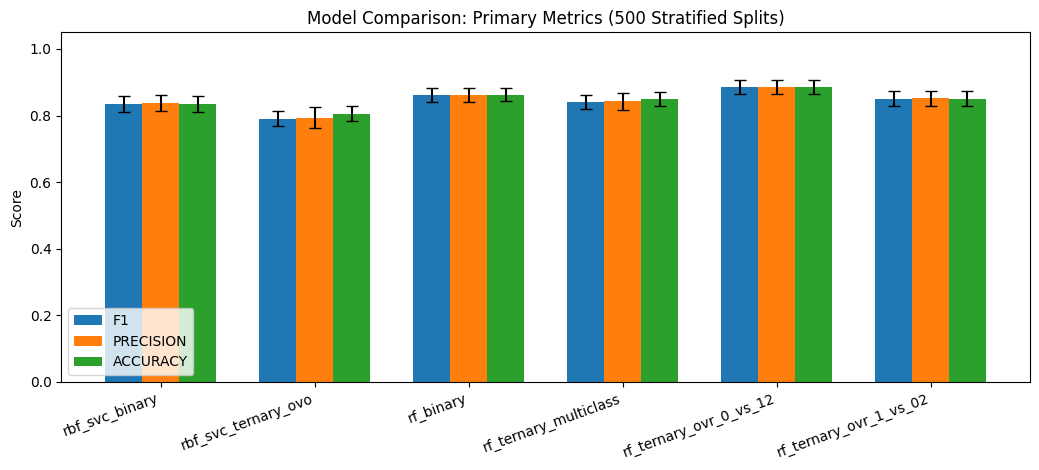

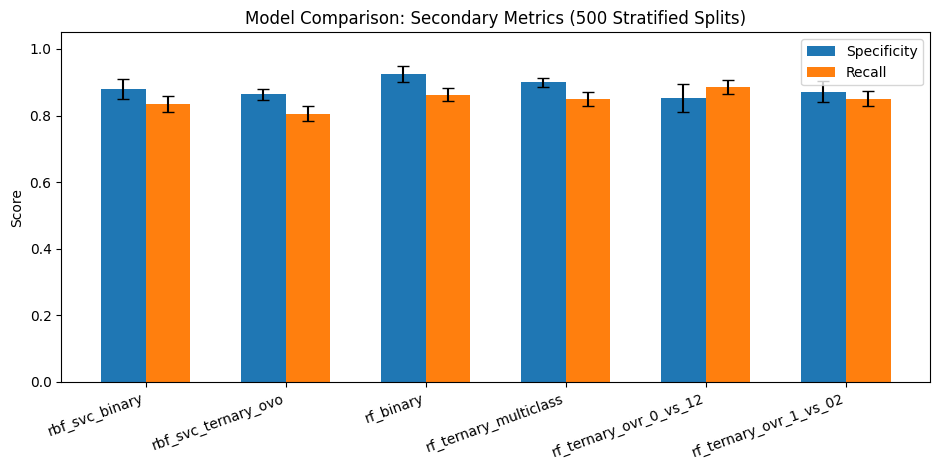

In [11]:
primary_metrics = ["f1", "precision", "accuracy"]
secondary_metrics = ["specificity", "recall"]
model_names = list(model_performance.keys())

fig, ax = plt.subplots(figsize=(10.5, 4.8))
positions = np.arange(len(model_names))
width = 0.24
offsets = np.linspace(-width, width, len(primary_metrics))
for metric_name, offset in zip(primary_metrics, offsets):
    means = [model_performance[model_name][metric_name]["mean"] for model_name in model_names]
    stds = [model_performance[model_name][metric_name]["std"] for model_name in model_names]
    ax.bar(positions + offset, means, width=width, yerr=stds, capsize=4, label=metric_name.upper())
ax.set_xticks(positions)
ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Primary Metrics (500 Stratified Splits)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 4.8))
positions = np.arange(len(model_names))
width = 0.32
offsets = np.linspace(-width / 2, width / 2, len(secondary_metrics))
for metric_name, offset in zip(secondary_metrics, offsets):
    means = [model_performance[model_name][metric_name]["mean"] for model_name in model_names]
    stds = [model_performance[model_name][metric_name]["std"] for model_name in model_names]
    ax.bar(positions + offset, means, width=width, yerr=stds, capsize=4, label=metric_name.capitalize())
ax.set_xticks(positions)
ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Secondary Metrics (500 Stratified Splits)")
ax.legend()
plt.tight_layout()
plt.show()

### Replication Outputs: Figure 3 (2x2) and Figure 4 (ROC)
This section reproduces the requested Figure 3 layout (excluding workflow) and Figure 4 ROC comparisons using 500 stratified splits and model IDs 1-9.

In [12]:
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import roc_curve, auc

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from scipy.special import gamma as gamma_fn
from scipy.special import kv
from scipy.spatial.distance import cdist


def _resolve_gamma_value(gamma, X):
    if isinstance(gamma, str):
        if gamma == "scale":
            n_features = X.shape[1]
            x_var = float(np.var(X))
            if x_var <= 0.0:
                x_var = 1.0
            return 1.0 / (n_features * x_var)
        if gamma == "auto":
            return 1.0 / float(X.shape[1])
        raise ValueError(f"Unsupported gamma string: {gamma}")
    return float(gamma)


def _matern_kernel_matrix(X, Y, nu, gamma_value):
    r = cdist(X, Y, metric="euclidean")
    beta = 2.0 * np.sqrt(nu * gamma_value) * r
    factor = (2.0 ** (1.0 - nu)) / gamma_fn(nu)

    K = np.empty_like(beta, dtype=float)
    zero_mask = beta == 0
    K[zero_mask] = 1.0

    nonzero = ~zero_mask
    b = beta[nonzero]
    K[nonzero] = factor * (b**nu) * kv(nu, b)
    return K


class _MaternPrecomputedSVC(BaseEstimator, ClassifierMixin):
    def __init__(self, C, nu, gamma, probability, random_state):
        self.C = float(C)
        self.nu = float(nu)
        self.gamma = gamma
        self.probability = bool(probability)
        self.random_state = random_state

        self.classes_ = None
        self._svc = None
        self._X_train = None
        self._gamma_value = None

    def fit(self, X, y):
        self._gamma_value = _resolve_gamma_value(self.gamma, X)
        self._X_train = X
        K_train = _matern_kernel_matrix(X, X, nu=self.nu, gamma_value=self._gamma_value)
        self._svc = SVC(kernel="precomputed", C=self.C, probability=self.probability, random_state=self.random_state)
        self._svc.fit(K_train, y)
        self.classes_ = self._svc.classes_
        return self

    def predict(self, X):
        K = _matern_kernel_matrix(X, self._X_train, nu=self.nu, gamma_value=self._gamma_value)
        return self._svc.predict(K)

    def predict_proba(self, X):
        K = _matern_kernel_matrix(X, self._X_train, nu=self.nu, gamma_value=self._gamma_value)
        return self._svc.predict_proba(K)


def make_svc_rbf(probability, c, gamma, random_state):
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="rbf", C=c, gamma=gamma, probability=probability, random_state=random_state)),
        ]
    )


def make_svc_matern(probability, c, nu, gamma, random_state):
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svc", _MaternPrecomputedSVC(C=c, nu=nu, gamma=gamma, probability=probability, random_state=random_state)),
        ]
    )


def build_model_from_spec(spec, y_type, random_seed):
    probability = True
    family = spec["family"]
    kernel = spec.get("kernel")

    if family == "svc":
        if kernel == "rbf":
            return make_svc_rbf(probability=probability, c=float(spec["C"]), gamma=spec.get("gamma", "scale"), random_state=random_seed)
        if kernel == "matern":
            return make_svc_matern(probability=probability, c=float(spec["C"]), nu=float(spec["nu"]), gamma=spec.get("gamma", "scale"), random_state=random_seed)
        raise ValueError(f"Unsupported SVC kernel: {kernel}")

    if family == "rf":
        return RandomForestClassifier(n_estimators=500, random_state=random_seed, class_weight="balanced", n_jobs=-1)

    raise ValueError(f"Unknown model family: {family}")

MODEL_SPECS = {
    1: {"id": 1, "name": "binary_rbf_svc", "task": "binary", "family": "svc", "multiclass": "direct", "kernel": "rbf", "C": 10, "gamma": 1},
    2: {"id": 2, "name": "ternary_rbf_svc_ovo", "task": "ternary", "family": "svc", "multiclass": "ovo", "kernel": "rbf", "C": 10, "gamma": 1},
    3: {"id": 3, "name": "binary_rf", "task": "binary", "family": "rf", "multiclass": "direct"},
    4: {"id": 4, "name": "ternary_rf_multiclass", "task": "ternary", "family": "rf", "multiclass": "direct"},
    5: {"id": 5, "name": "ternary_rf_ovr_0_vs_12", "task": "ternary", "family": "rf", "multiclass": "ovr", "positive_class": 0},
    6: {"id": 6, "name": "ternary_rf_ovr_1_vs_02", "task": "ternary", "family": "rf", "multiclass": "ovr", "positive_class": 1},
    7: {"id": 7, "name": "ternary_rf_ovr_2_vs_01", "task": "ternary", "family": "rf", "multiclass": "ovr", "positive_class": 2},
    8: {"id": 8, "name": "binary_matern_svc", "task": "binary", "family": "svc", "multiclass": "direct", "kernel": "matern", "C": 10, "nu": 2.5},
    9: {"id": 9, "name": "ternary_matern_svc_ovo", "task": "ternary", "family": "svc", "multiclass": "ovo", "kernel": "matern", "C": 1, "nu": 1},
}

N_SPLITS = 500
RANDOM_STATE = 42

splitter_binary = StratifiedShuffleSplit(n_splits=N_SPLITS, train_size=2/3, test_size=1/3, random_state=RANDOM_STATE)
splitter_ternary = StratifiedShuffleSplit(n_splits=N_SPLITS, train_size=2/3, test_size=1/3, random_state=RANDOM_STATE)


def compute_macro_specificity_from_cm(cm: np.ndarray) -> float:
    specs = []
    for class_idx in range(cm.shape[0]):
        tp = cm[class_idx, class_idx]
        fp = cm[:, class_idx].sum() - tp
        fn = cm[class_idx, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return float(np.mean(specs))


def evaluate_model_over_splits(model_id: int):
    spec = MODEL_SPECS[model_id]
    task = spec["task"]

    if task == "binary":
        X_task, y_task = X, y
        split_iter = splitter_binary.split(X_task, y_task)
        labels = [0, 1]
    else:
        X_task, y_task = X_ternary, y_ternary
        split_iter = splitter_ternary.split(X_task, y_task)
        labels = [0, 1, 2]

    metric_series = {"precision": [], "recall": [], "accuracy": [], "f1": [], "specificity": []}
    class_recall_series = {0: [], 1: [], 2: []}
    class_specificity_series = {0: [], 1: [], 2: []}

    for train_index, test_index in split_iter:
        X_train, X_test = X_task[train_index], X_task[test_index]
        y_train_raw, y_test_raw = y_task[train_index], y_task[test_index]

        y_type = "binary"
        y_train, y_test = y_train_raw, y_test_raw

        if model_id in [5, 6, 7]:
            pos_class = spec["positive_class"]
            y_train = np.where(y_train_raw == pos_class, 0, 1)
            y_test = np.where(y_test_raw == pos_class, 0, 1)
            labels = [0, 1]
        elif task == "ternary":
            y_type = "ternary"
            labels = [0, 1, 2]

        estimator = build_model_from_spec(spec, y_type=y_type, random_seed=RANDOM_STATE)
        estimator.fit(X_train, y_train)
        y_pred = estimator.predict(X_test)

        precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
        acc = accuracy_score(y_test, y_pred)

        if len(labels) == 2:
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=labels).ravel()
            spec_macro = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        else:
            cm = confusion_matrix(y_test, y_pred, labels=labels)
            spec_macro = compute_macro_specificity_from_cm(cm)

            recalls_per_class = precision_recall_fscore_support(y_test, y_pred, labels=labels, average=None, zero_division=0)[1]
            for class_idx in [0, 1, 2]:
                class_recall_series[class_idx].append(float(recalls_per_class[class_idx]))

            for class_idx in [0, 1, 2]:
                tp = cm[class_idx, class_idx]
                fp = cm[:, class_idx].sum() - tp
                fn = cm[class_idx, :].sum() - tp
                tn = cm.sum() - (tp + fp + fn)
                class_spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
                class_specificity_series[class_idx].append(float(class_spec))

        metric_series["precision"].append(float(precision))
        metric_series["recall"].append(float(recall))
        metric_series["accuracy"].append(float(acc))
        metric_series["f1"].append(float(f1))
        metric_series["specificity"].append(float(spec_macro))

    stats = {k: {"mean": float(np.mean(v)), "std": float(np.std(v, ddof=1))} for k, v in metric_series.items()}
    class_stats = {
        "recall": {k: {"mean": float(np.mean(v)), "std": float(np.std(v, ddof=1))} if len(v) else {"mean": np.nan, "std": np.nan} for k, v in class_recall_series.items()},
        "specificity": {k: {"mean": float(np.mean(v)), "std": float(np.std(v, ddof=1))} if len(v) else {"mean": np.nan, "std": np.nan} for k, v in class_specificity_series.items()},
    }
    return stats, class_stats


all_model_stats = {}
all_class_stats = {}
for mid in range(1, 10):
    stats, class_stats = evaluate_model_over_splits(mid)
    all_model_stats[mid] = stats
    all_class_stats[mid] = class_stats

print("Computed model statistics for IDs 1-9 over 500 splits.")

Computed model statistics for IDs 1-9 over 500 splits.


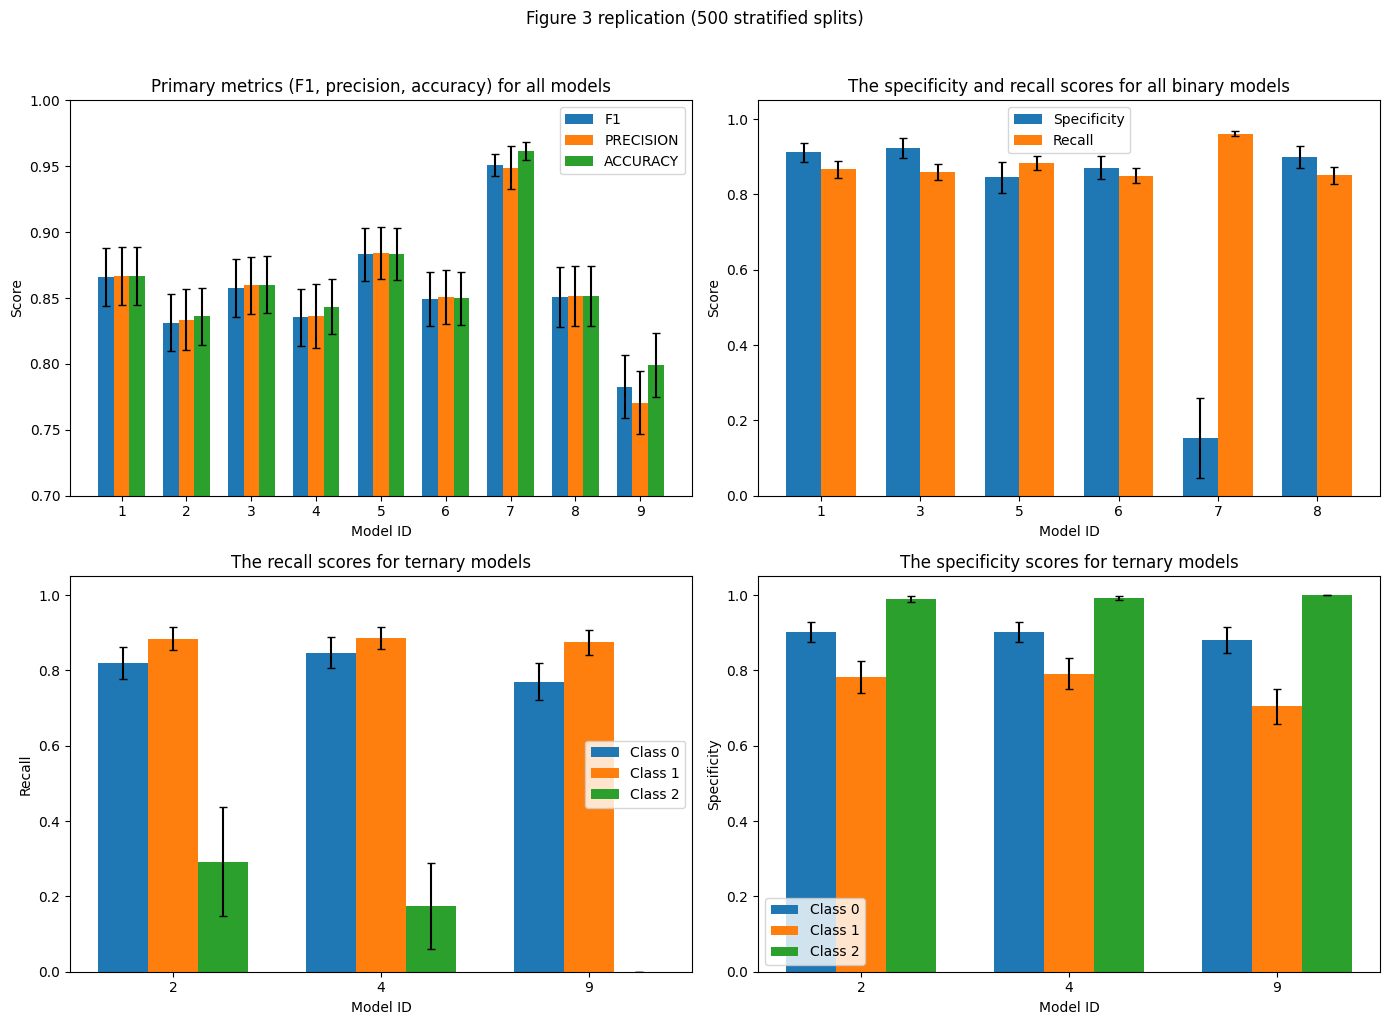

Saved Figure 3 to: outputs/figures/figure3_replication_2x2.png


In [13]:
# Figure 3 replication (workflow panel removed)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_ids_all = list(range(1, 10))
model_ids_binary = [1, 3, 5, 6, 7, 8]
model_ids_ternary = [2, 4, 9]

# (a) F1, Precision, Accuracy for model IDs 1-9
ax = axes[0, 0]
metrics_a = ["f1", "precision", "accuracy"]
x = np.arange(len(model_ids_all))
w = 0.24
for i, metric in enumerate(metrics_a):
    means = [all_model_stats[mid][metric]["mean"] for mid in model_ids_all]
    stds = [all_model_stats[mid][metric]["std"] for mid in model_ids_all]
    ax.bar(x + (i - 1) * w, means, width=w, yerr=stds, capsize=3, label=metric.upper())
ax.set_xticks(x)
ax.set_xticklabels(model_ids_all)
ax.set_ylim(0.7, 1.0)
ax.set_xlabel("Model ID")
ax.set_ylabel("Score")
ax.set_title("Primary metrics (F1, precision, accuracy) for all models")
ax.legend()

# (b) Specificity, Recall for model IDs 1,3,5,6,7,8
ax = axes[0, 1]
metrics_b = ["specificity", "recall"]
x = np.arange(len(model_ids_binary))
w = 0.35
for i, metric in enumerate(metrics_b):
    means = [all_model_stats[mid][metric]["mean"] for mid in model_ids_binary]
    stds = [all_model_stats[mid][metric]["std"] for mid in model_ids_binary]
    ax.bar(x + (i - 0.5) * w, means, width=w, yerr=stds, capsize=3, label=metric.capitalize())
ax.set_xticks(x)
ax.set_xticklabels(model_ids_binary)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model ID")
ax.set_ylabel("Score")
ax.set_title("The specificity and recall scores for all binary models")
ax.legend()

# (c) Recall by class for ternary models 2,4,9
ax = axes[1, 0]
x = np.arange(len(model_ids_ternary))
w = 0.24
for class_idx in [0, 1, 2]:
    means = [all_class_stats[mid]["recall"][class_idx]["mean"] for mid in model_ids_ternary]
    stds = [all_class_stats[mid]["recall"][class_idx]["std"] for mid in model_ids_ternary]
    ax.bar(x + (class_idx - 1) * w, means, width=w, yerr=stds, capsize=3, label=f"Class {class_idx}")
ax.set_xticks(x)
ax.set_xticklabels(model_ids_ternary)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model ID")
ax.set_ylabel("Recall")
ax.set_title("The recall scores for ternary models")
ax.legend()

# (d) Specificity by class for ternary models 2,4,9
ax = axes[1, 1]
x = np.arange(len(model_ids_ternary))
w = 0.24
for class_idx in [0, 1, 2]:
    means = [all_class_stats[mid]["specificity"][class_idx]["mean"] for mid in model_ids_ternary]
    stds = [all_class_stats[mid]["specificity"][class_idx]["std"] for mid in model_ids_ternary]
    ax.bar(x + (class_idx - 1) * w, means, width=w, yerr=stds, capsize=3, label=f"Class {class_idx}")
ax.set_xticks(x)
ax.set_xticklabels(model_ids_ternary)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model ID")
ax.set_ylabel("Specificity")
ax.set_title("The specificity scores for ternary models")
ax.legend()

plt.suptitle("Figure 3 replication (500 stratified splits)", y=1.02)
plt.tight_layout()

outputs_dir = Path("outputs")
figures_dir = outputs_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
figure3_path = figures_dir / "figure3_replication_2x2.png"
plt.savefig(figure3_path, dpi=250, bbox_inches="tight")
plt.show()

print(f"Saved Figure 3 to: {figure3_path}")

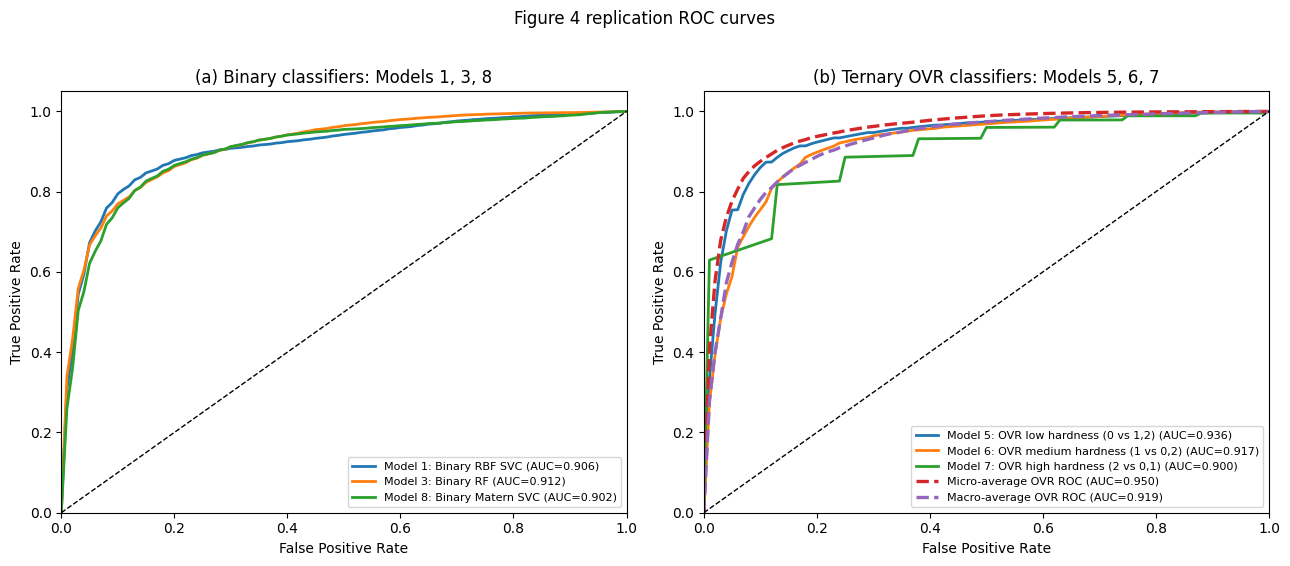

Saved Figure 4 to: outputs/figures/figure4_replication_roc.png


In [14]:
# Figure 4 replication
# (a) Binary models 1,3,8
# (b) Ternary OVR classifiers 5,6,7 + micro/macro averages


def mean_roc_over_splits(estimator_builder, X_data, y_data, splitter, positive_label=1):
    fpr_grid = np.linspace(0.0, 1.0, 101)
    tprs = []

    for train_idx, test_idx in splitter.split(X_data, y_data):
        X_train, X_test = X_data[train_idx], X_data[test_idx]
        y_train, y_test = y_data[train_idx], y_data[test_idx]

        est = estimator_builder()
        est.fit(X_train, y_train)

        if hasattr(est, "predict_proba"):
            scores = est.predict_proba(X_test)[:, 1]
        else:
            scores = est.decision_function(X_test)

        fpr, tpr, _ = roc_curve((y_test == positive_label).astype(int), scores)
        interp_tpr = np.interp(fpr_grid, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(fpr_grid, mean_tpr)
    return fpr_grid, mean_tpr, mean_auc


def mean_micro_macro_ovr_over_splits(X_data, y_multiclass, splitter):
    fpr_grid = np.linspace(0.0, 1.0, 101)
    micro_tprs = []
    macro_tprs = []

    for train_idx, test_idx in splitter.split(X_data, y_multiclass):
        X_train, X_test = X_data[train_idx], X_data[test_idx]
        y_train, y_test = y_multiclass[train_idx], y_multiclass[test_idx]

        # Same binary constructions used by models 5, 6, 7 (target class coded as 0)
        y_train_0 = np.where(y_train == 0, 0, 1)
        y_train_1 = np.where(y_train == 1, 0, 1)
        y_train_2 = np.where(y_train == 2, 0, 1)

        est5 = build_model_from_spec(MODEL_SPECS[5], y_type="binary", random_seed=RANDOM_STATE)
        est6 = build_model_from_spec(MODEL_SPECS[6], y_type="binary", random_seed=RANDOM_STATE)
        est7 = build_model_from_spec(MODEL_SPECS[7], y_type="binary", random_seed=RANDOM_STATE)

        est5.fit(X_train, y_train_0)
        est6.fit(X_train, y_train_1)
        est7.fit(X_train, y_train_2)

        # Use probability of the target class (coded as label 0) for class-vs-rest ROC
        s0 = est5.predict_proba(X_test)[:, 0]
        s1 = est6.predict_proba(X_test)[:, 0]
        s2 = est7.predict_proba(X_test)[:, 0]

        y_true_bin = np.column_stack([
            (y_test == 0).astype(int),
            (y_test == 1).astype(int),
            (y_test == 2).astype(int),
        ])
        score_mat = np.column_stack([s0, s1, s2])

        # Micro-average
        fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), score_mat.ravel())
        tpr_micro_interp = np.interp(fpr_grid, fpr_micro, tpr_micro)
        tpr_micro_interp[0] = 0.0
        micro_tprs.append(tpr_micro_interp)

        # Macro-average (mean across class-wise curves in this split)
        class_tprs = []
        for j in range(3):
            fpr_c, tpr_c, _ = roc_curve(y_true_bin[:, j], score_mat[:, j])
            tpr_c_interp = np.interp(fpr_grid, fpr_c, tpr_c)
            tpr_c_interp[0] = 0.0
            class_tprs.append(tpr_c_interp)
        macro_tprs.append(np.mean(class_tprs, axis=0))

    mean_micro_tpr = np.mean(micro_tprs, axis=0)
    mean_micro_tpr[-1] = 1.0
    mean_macro_tpr = np.mean(macro_tprs, axis=0)
    mean_macro_tpr[-1] = 1.0

    micro_auc = auc(fpr_grid, mean_micro_tpr)
    macro_auc = auc(fpr_grid, mean_macro_tpr)
    return (fpr_grid, mean_micro_tpr, micro_auc), (fpr_grid, mean_macro_tpr, macro_auc)


# Binary ROC curves for models 1, 3, 8
def builder_m1():
    return build_model_from_spec(MODEL_SPECS[1], y_type="binary", random_seed=RANDOM_STATE)

def builder_m3():
    return build_model_from_spec(MODEL_SPECS[3], y_type="binary", random_seed=RANDOM_STATE)

def builder_m8():
    return build_model_from_spec(MODEL_SPECS[8], y_type="binary", random_seed=RANDOM_STATE)

splitter_for_roc_binary = StratifiedShuffleSplit(n_splits=N_SPLITS, train_size=2/3, test_size=1/3, random_state=RANDOM_STATE)
roc_m1 = mean_roc_over_splits(builder_m1, X, y, splitter_for_roc_binary)
roc_m3 = mean_roc_over_splits(builder_m3, X, y, splitter_for_roc_binary)
roc_m8 = mean_roc_over_splits(builder_m8, X, y, splitter_for_roc_binary)

# OVR ROC curves for models 5, 6, 7 using ternary data mapped to binary each time
splitter_for_roc_ternary = StratifiedShuffleSplit(n_splits=N_SPLITS, train_size=2/3, test_size=1/3, random_state=RANDOM_STATE)

y_ovr_0 = np.where(y_ternary == 0, 0, 1)
y_ovr_1 = np.where(y_ternary == 1, 0, 1)
y_ovr_2 = np.where(y_ternary == 2, 0, 1)


def builder_m5():
    return build_model_from_spec(MODEL_SPECS[5], y_type="binary", random_seed=RANDOM_STATE)

def builder_m6():
    return build_model_from_spec(MODEL_SPECS[6], y_type="binary", random_seed=RANDOM_STATE)

def builder_m7():
    return build_model_from_spec(MODEL_SPECS[7], y_type="binary", random_seed=RANDOM_STATE)

roc_m5 = mean_roc_over_splits(builder_m5, X_ternary, y_ovr_0, splitter_for_roc_ternary)
roc_m6 = mean_roc_over_splits(builder_m6, X_ternary, y_ovr_1, splitter_for_roc_ternary)
roc_m7 = mean_roc_over_splits(builder_m7, X_ternary, y_ovr_2, splitter_for_roc_ternary)
roc_micro, roc_macro = mean_micro_macro_ovr_over_splits(X_ternary, y_ternary, splitter_for_roc_ternary)

# Plot Figure 4
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
for (fpr, tpr, roc_auc), label in [
    (roc_m1, "Model 1: Binary RBF SVC"),
    (roc_m3, "Model 3: Binary RF"),
    (roc_m8, "Model 8: Binary Matern SVC"),
]:
    ax.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("(a) Binary classifiers: Models 1, 3, 8")
ax.legend(fontsize=8)

ax = axes[1]
for (fpr, tpr, roc_auc), label in [
    (roc_m5, "Model 5: OVR low hardness (0 vs 1,2)"),
    (roc_m6, "Model 6: OVR medium hardness (1 vs 0,2)"),
    (roc_m7, "Model 7: OVR high hardness (2 vs 0,1)"),
    (roc_micro, "Micro-average OVR ROC"),
    (roc_macro, "Macro-average OVR ROC"),
]:
    style = "--" if "average" in label else "-"
    width = 2.4 if "average" in label else 2.0
    ax.plot(fpr, tpr, linestyle=style, linewidth=width, label=f"{label} (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("(b) Ternary OVR classifiers: Models 5, 6, 7")
ax.legend(fontsize=8)

plt.suptitle("Figure 4 replication ROC curves", y=1.02)
plt.tight_layout()

figure4_path = figures_dir / "figure4_replication_roc.png"
plt.savefig(figure4_path, dpi=250, bbox_inches="tight")
plt.show()

print(f"Saved Figure 4 to: {figure4_path}")

### Extension: Neural Network (MLP) for Ternary Hardness Prediction
This extension searches ANN architectures and regularization strengths using repeated stratified splits, then compares ANN performance to the baseline ternary models.

Saved ANN extension metrics to: outputs/results/ann_extension_metrics.csv
Top ANN candidates by weighted F1:


,hidden_layer_sizes,alpha,f1_mean,f1_std,accuracy_mean,accuracy_std,recall_mean,recall_std,specificity_mean,specificity_std
0,"(64, 32)",0.0001,0.720909,0.033545,0.733678,0.035332,0.733678,0.035332,0.823600,0.021695
1,"(64, 32)",0.0010,0.720773,0.033439,0.733534,0.035258,0.733534,0.035258,0.823485,0.021590
2,"(32,)",0.0010,0.711653,0.044818,0.720481,0.056459,0.720481,0.056459,0.819009,0.023981
3,"(32,)",0.0001,0.711629,0.044794,0.720457,0.056437,0.720457,0.056437,0.818990,0.023961
4,"(64,)",0.0001,0.703034,0.032803,0.710168,0.039947,0.710168,0.039947,0.814155,0.018441


Baseline vs ANN (ternary task):


,model,f1_mean,accuracy_mean
0,Model 2 (RBF SVC OVO),0.831188,0.836231
1,Model 4 (RF multiclass),0.835376,0.843490
2,Model 9 (Matern SVC OVO),0.782831,0.799413
3,Best ANN candidate,0.720909,0.733678


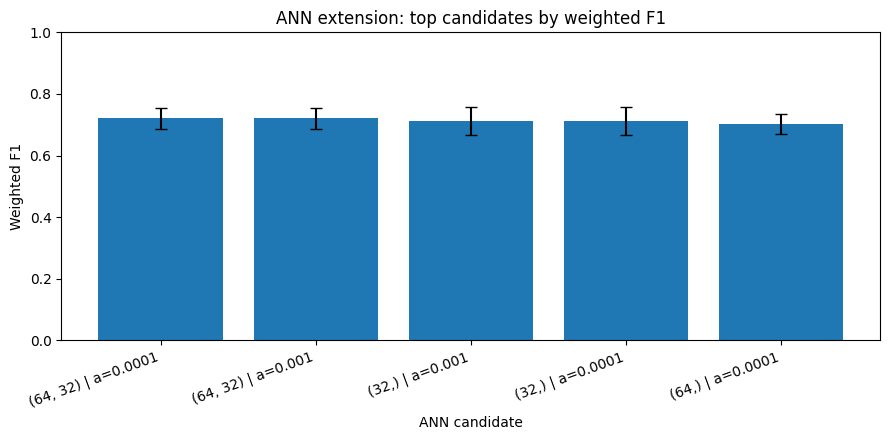

Saved ANN extension figure to: outputs/figures/ann_extension_top_candidates.png


In [15]:
import pandas as pd
from sklearn.neural_network import MLPClassifier

# Extension goal: compare ANN vs existing methods (not architecture exploration)
ANN_SPLITS = 200
ann_splitter = StratifiedShuffleSplit(
    n_splits=ANN_SPLITS,
    train_size=2 / 3,
    test_size=1 / 3,
    random_state=42,
)

# Keep a compact candidate set, then compare best ANN against baselines
ann_candidates = [
    {"hidden_layer_sizes": (32,), "alpha": 1e-4},
    {"hidden_layer_sizes": (64,), "alpha": 1e-4},
    {"hidden_layer_sizes": (64, 32), "alpha": 1e-4},
    {"hidden_layer_sizes": (64, 32), "alpha": 1e-3},
]


def evaluate_ann_candidate(hidden_layer_sizes, alpha):
    series = {"precision": [], "recall": [], "accuracy": [], "f1": [], "specificity": []}

    for train_idx, test_idx in ann_splitter.split(X_ternary, y_ternary):
        X_train, X_test = X_ternary[train_idx], X_ternary[test_idx]
        y_train, y_test = y_ternary[train_idx], y_ternary[test_idx]

        ann_model = Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "mlp",
                    MLPClassifier(
                        hidden_layer_sizes=hidden_layer_sizes,
                        alpha=alpha,
                        activation="relu",
                        solver="adam",
                        learning_rate="adaptive",
                        early_stopping=True,
                        max_iter=3000,
                        random_state=42,
                    ),
                ),
            ]
        )

        ann_model.fit(X_train, y_train)
        y_pred = ann_model.predict(X_test)

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0,
        )
        accuracy = accuracy_score(y_test, y_pred)

        cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
        per_class_specificity = []
        for class_idx in range(cm.shape[0]):
            tp = cm[class_idx, class_idx]
            fp = cm[:, class_idx].sum() - tp
            fn = cm[class_idx, :].sum() - tp
            tn = cm.sum() - (tp + fp + fn)
            class_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            per_class_specificity.append(class_specificity)
        specificity = float(np.mean(per_class_specificity))

        series["precision"].append(float(precision))
        series["recall"].append(float(recall))
        series["accuracy"].append(float(accuracy))
        series["f1"].append(float(f1))
        series["specificity"].append(float(specificity))

    return {
        metric: {
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)),
        }
        for metric, values in series.items()
    }


# Train/evaluate ANN candidates and pick the best by weighted F1
ann_rows = []
for cand in ann_candidates:
    stats = evaluate_ann_candidate(cand["hidden_layer_sizes"], cand["alpha"])
    ann_rows.append(
        {
            "model": f"ANN {cand['hidden_layer_sizes']} a={cand['alpha']}",
            "f1_mean": stats["f1"]["mean"],
            "f1_std": stats["f1"]["std"],
            "accuracy_mean": stats["accuracy"]["mean"],
            "accuracy_std": stats["accuracy"]["std"],
            "recall_mean": stats["recall"]["mean"],
            "recall_std": stats["recall"]["std"],
            "specificity_mean": stats["specificity"]["mean"],
            "specificity_std": stats["specificity"]["std"],
        }
    )

ann_results_df = pd.DataFrame(ann_rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)
best_ann = ann_results_df.iloc[0]

# Compare best ANN directly against the existing methods from Figure 3 stats
if "all_model_stats" not in globals():
    raise RuntimeError("Run the Figure 3 stats cell first so all_model_stats is available.")

comparison_rows = []
for mid in range(1, 10):
    comparison_rows.append(
        {
            "model": f"Model {mid}",
            "f1_mean": all_model_stats[mid]["f1"]["mean"],
            "accuracy_mean": all_model_stats[mid]["accuracy"]["mean"],
        }
    )
comparison_rows.append(
    {
        "model": "Best ANN",
        "f1_mean": float(best_ann["f1_mean"]),
        "accuracy_mean": float(best_ann["accuracy_mean"]),
    }
)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("f1_mean", ascending=False).reset_index(drop=True)

# Save report-ready extension outputs
outputs_results_dir = Path("outputs") / "results"
outputs_results_dir.mkdir(parents=True, exist_ok=True)
comparison_csv_path = outputs_results_dir / "ann_vs_methods_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)

print(f"Saved comparison table to: {comparison_csv_path}")
print("ANN extension result: best ANN compared with Models 1-9")
display(comparison_df)

# Plot F1 comparison
plt.figure(figsize=(10, 4.8))
plt.bar(comparison_df["model"], comparison_df["f1_mean"])
plt.ylim(0.0, 1.0)
plt.ylabel("Weighted F1")
plt.xlabel("Method")
plt.title("Extension comparison: Best ANN vs Models 1-9")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
ann_compare_fig = Path("outputs") / "figures" / "ann_vs_methods_f1.png"
plt.savefig(ann_compare_fig, dpi=250, bbox_inches="tight")
plt.show()
print(f"Saved comparison figure to: {ann_compare_fig}")